# AutoEncoder on MNIST: Reconstruction and Latent Representation

AutoEncoder 是最基础的生成模型之一。它学习两个函数：

- **Encoder**: 把输入图片 $x$ 压缩成 64 维 latent vector $z$。
- **Decoder**: 从 latent vector $z$ 重建图片 $\hat{x}$。

本 notebook 使用 MNIST 做一个小型 AutoEncoder。目标不是追求最清晰的重建图像，而是理解：

- 为什么 autoencoder 可以学到 latent representation。
- 如何用 PCA 把 64 维 latent vectors 可视化到 2D。
- 为什么 PCA 图只是可视化，不是 decoder 的输入空间。
- 如何在原始 latent space 中做插值，并把插值点 decode 成图像序列。

每张 MNIST 图片可以看作 $x \in \mathbb{R}^{784}$。AutoEncoder 学习：

$$z = f_{\text{encoder}}(x), \quad \hat{x} = f_{\text{decoder}}(z)$$

训练目标是让 $\hat{x}$ 尽量接近原图 $x$。

**AI 使用指引。** 如果 autoencoder 和 classifier 的区别不清楚，可以问 AI：`AutoEncoder 为什么不需要 label？它和 MNIST 分类模型的输入、输出、loss 分别有什么不同？` 重点是理解 autoencoder 学的是重建，不是类别预测。

## 1. 准备环境

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

# Keep this teaching example CPU-only.
device = torch.device("cuda")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "generative_models" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs" / "figures"

SAVE_FIGURES = False

## 2. 准备 MNIST 数据

AutoEncoder 不使用 digit label 训练。训练时只需要图片本身：输入是 `images`，目标也是同一批 `images`。

这里使用完整 MNIST training set 和 test set。训练时使用官方 60,000 张 training images，latent PCA 和插值可视化使用官方 10,000 张 test images。

In [ ]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

BATCH_SIZE = 256

train_dataset = full_train_dataset
eval_dataset = test_dataset

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"training images used = {len(train_dataset)}")
print(f"test images used = {len(eval_dataset)}")

images, labels = next(iter(train_loader))
print(f"images.shape = {tuple(images.shape)}")
print(f"labels.shape = {tuple(labels.shape)}")
print("Labels are kept only for visualization, not for autoencoder training.")

training images used = 60000
test images used = 10000
images.shape = (2048, 1, 28, 28)
labels.shape = (2048,)
Labels are kept only for visualization, not for autoencoder training.


## 3. 定义 AutoEncoder

这里使用最简单的 MLP AutoEncoder。图片先被 flatten 成 784 维向量，再压缩到 64 维 latent vector。

- Encoder: `(B, 784) -> (B, 64)`
- Decoder: `(B, 64) -> (B, 784)`

Decoder 最后一层使用 `nn.Sigmoid()`，因为 MNIST tensor 的像素值在 0 到 1 之间。

**AI 使用指引。** 如果 latent dimension 的意义不清楚，可以问 AI：`AutoEncoder 中 64 维 latent vector 是怎样的信息瓶颈？如果 latent dimension 进一步变小或变大，会如何影响压缩、重建质量和 latent visualization？` 重点是理解 latent dimension 是信息瓶颈，不是类别数。

In [8]:
LATENT_DIM = 64


class MNISTAutoEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, images):
        latent = self.encoder(images)
        reconstruction_flat = self.decoder(latent)
        return reconstruction_flat, latent


model = MNISTAutoEncoder(latent_dim=LATENT_DIM).to(device)
print(model)

MNISTAutoEncoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


检查一个 batch 经过 encoder 和 decoder 后的形状。

In [9]:
images = images.to(device)
reconstruction_flat, latent = model(images)

print(f"input images.shape = {tuple(images.shape)}")
print(f"latent.shape = {tuple(latent.shape)}")
print(f"reconstruction_flat.shape = {tuple(reconstruction_flat.shape)}")

input images.shape = (2048, 1, 28, 28)
latent.shape = (2048, 64)
reconstruction_flat.shape = (2048, 784)


## 4. Loss 和训练循环

AutoEncoder 的 loss 比较重建图像 $\hat{x}$ 和原始图像 $x$。这里使用 mean squared error:

$$\text{loss} = \frac{1}{784}\sum_{j=1}^{784}(\hat{x}_j - x_j)^2$$

注意，这里不需要 label。

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 30

history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for images, _labels in train_loader:
        images = images.to(device)
        targets = images.view(images.shape[0], -1)

        optimizer.zero_grad()
        reconstruction_flat, latent = model(images)
        loss = criterion(reconstruction_flat, targets)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    average_loss = total_loss / total_examples
    history.append({"epoch": epoch + 1, "loss": average_loss})
    print(f"epoch {epoch + 1}: reconstruction loss = {average_loss:.5f}")

epoch 1: reconstruction loss = 0.11396
epoch 2: reconstruction loss = 0.06968
epoch 3: reconstruction loss = 0.05878
epoch 4: reconstruction loss = 0.05054
epoch 5: reconstruction loss = 0.04422
epoch 6: reconstruction loss = 0.03947
epoch 7: reconstruction loss = 0.03536
epoch 8: reconstruction loss = 0.03164
epoch 9: reconstruction loss = 0.02801
epoch 10: reconstruction loss = 0.02500
epoch 11: reconstruction loss = 0.02299
epoch 12: reconstruction loss = 0.02115
epoch 13: reconstruction loss = 0.01963
epoch 14: reconstruction loss = 0.01833
epoch 15: reconstruction loss = 0.01747
epoch 16: reconstruction loss = 0.01646
epoch 17: reconstruction loss = 0.01583
epoch 18: reconstruction loss = 0.01519
epoch 19: reconstruction loss = 0.01454
epoch 20: reconstruction loss = 0.01411
epoch 21: reconstruction loss = 0.01363
epoch 22: reconstruction loss = 0.01316
epoch 23: reconstruction loss = 0.01282
epoch 24: reconstruction loss = 0.01241
epoch 25: reconstruction loss = 0.01221
epoch 26:

## 5. 查看重建结果

下面比较原图和 AutoEncoder 重建图。因为 latent vector 只有 64 维，重建图通常会更模糊；这正是压缩带来的信息损失。

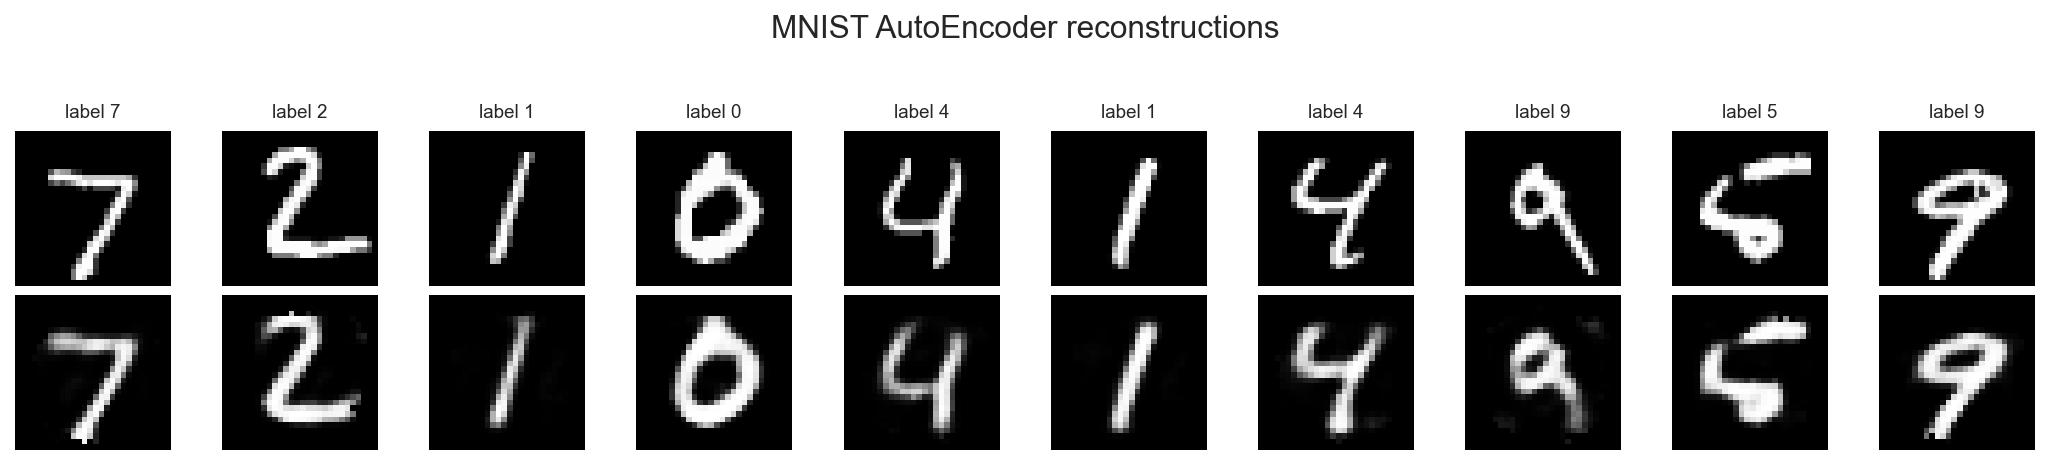

In [11]:
def show_reconstructions(model, loader, num_images=10):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:num_images].to(device)

    with torch.no_grad():
        reconstruction_flat, latent = model(images)
        reconstructions = reconstruction_flat.view(-1, 1, 28, 28).cpu()

    originals = images.cpu()
    fig, axes = plt.subplots(2, num_images, figsize=(1.4 * num_images, 3.0))

    for col in range(num_images):
        axes[0, col].imshow(originals[col].squeeze(0), cmap="gray")
        axes[0, col].set_title(f"label {labels[col].item()}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(reconstructions[col].squeeze(0), cmap="gray")
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Recon", fontsize=11)
    fig.suptitle("MNIST AutoEncoder reconstructions", y=1.03)
    plt.tight_layout()
    return fig


fig = show_reconstructions(model, test_loader, num_images=10)

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "autoencoder_mnist_reconstructions.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "autoencoder_mnist_reconstructions.svg", bbox_inches="tight")

## 6. 收集 latent vectors

训练后，我们把 test subset 中的图片送入 encoder，得到每张图片的 latent vector。虽然训练时没有用 label，但可视化时可以用 label 给点上色，观察不同数字是否在 latent space 中形成结构。

In [12]:
def collect_latents(model, loader):
    model.eval()
    latent_batches = []
    label_batches = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            latent = model.encoder(images)
            latent_batches.append(latent.cpu())
            label_batches.append(labels)

    latents = torch.cat(latent_batches, dim=0).numpy()
    labels = torch.cat(label_batches, dim=0).numpy()
    return latents, labels


latents, latent_labels = collect_latents(model, test_loader)
print(f"latents.shape = {latents.shape}")
print(f"latent_labels.shape = {latent_labels.shape}")

latents.shape = (10000, 64)
latent_labels.shape = (10000,)


## 7. PCA 可视化 latent representation

`LATENT_DIM = 64` 时，latent vector 是 64 维，无法直接画在二维平面上。PCA 会找两个线性方向，把 64 维 latent vectors 投影到 2D，方便观察结构。

重要限制：PCA 图中的坐标只是投影后的坐标，不是 decoder 原本接收的 64 维 latent vector。不能直接把 PCA 图上的二维坐标送进 decoder。

**AI 使用指引。** 如果 PCA 图和真实 latent space 的关系不清楚，可以问 AI：`PCA 把 64 维 latent vectors 投影到 2D 后，为什么这个 2D 坐标不能直接送进 decoder？PCA 可视化保留了什么，又丢失了什么？` 重点是区分“可视化坐标”和“decoder 输入空间”。

In [13]:
pca = PCA(n_components=2, random_state=SEED)
latent_2d = pca.fit_transform(latents)

print(f"PCA explained variance ratio = {pca.explained_variance_ratio_}")

PCA explained variance ratio = [0.2200286  0.11138237]


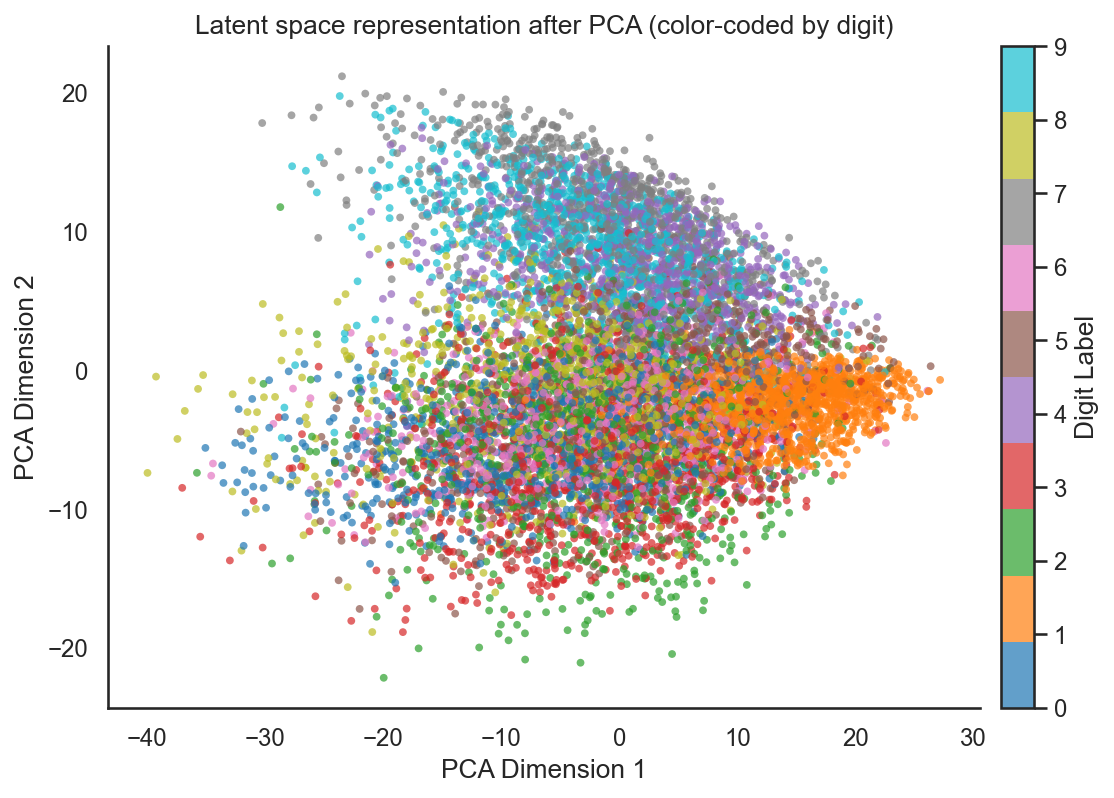

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))

scatter = ax.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=14,
    alpha=0.70,
    edgecolors="none",
)

cbar = plt.colorbar(scatter, ax=ax, ticks=range(10), pad=0.02)
cbar.set_label("Digit Label")

ax.set_title("Latent space representation after PCA (color-coded by digit)")
ax.set_xlabel("PCA Dimension 1")
ax.set_ylabel("PCA Dimension 2")
sns.despine(ax=ax)
plt.tight_layout()

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "autoencoder_mnist_latent_pca.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "autoencoder_mnist_latent_pca.svg", bbox_inches="tight")

## 8. Latent interpolation: 在原始 latent space 中插值

普通 AutoEncoder 的 latent space 没有被强制变成标准正态分布，也没有被强制满足“直线一定对应语义平滑变化”。因此：

- 不要把 PCA 图上的二维坐标直接拿来插值并 decode。
- 可以在原始 64 维 latent vectors 之间做线性插值，再用 decoder 观察结果。
- 插值结果是否平滑，是对模型学到的 latent structure 的经验观察，不是理论保证。

下面选取几对不同数字，把它们编码成 latent vectors，在原始 latent space 中做直线插值，然后 decode 出每一步的图像。

**AI 使用指引。** 如果 latent interpolation 的含义不清楚，可以问 AI：`普通 AutoEncoder 的 latent space 为什么不保证任意两点之间的直线都有清晰语义？为什么 VAE 通常更强调结构化 latent space？` 重点是理解 interpolation 是诊断和可视化，不是 AE 自动保证的性质。

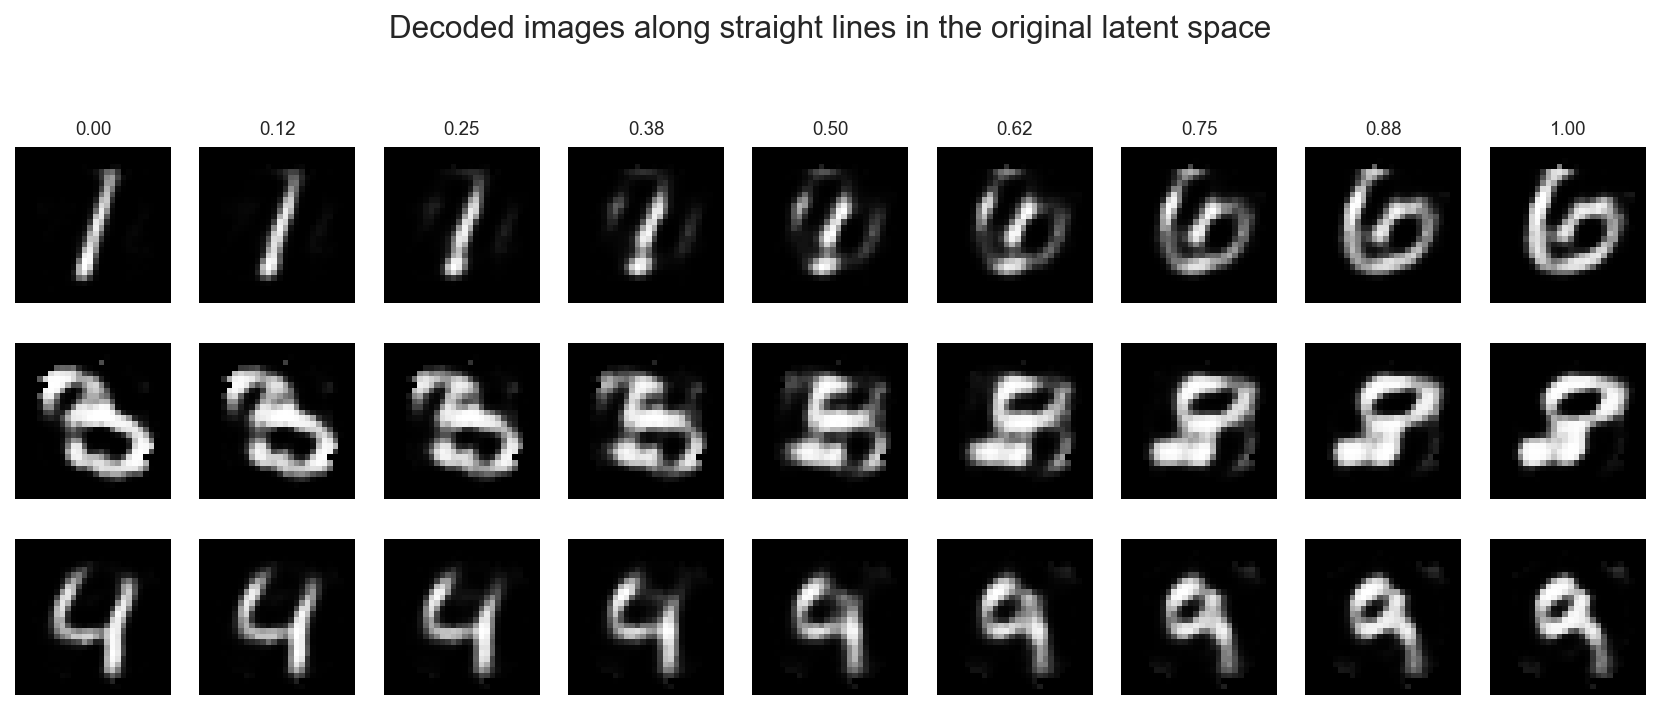

In [16]:
def find_first_image_with_label(dataset, target_label):
    for image, label in dataset:
        if label == target_label:
            return image, label
    raise ValueError(f"Label {target_label} not found")


def interpolate_between_digits(model, dataset, start_digit, end_digit, steps=9):
    start_image, _ = find_first_image_with_label(dataset, start_digit)
    end_image, _ = find_first_image_with_label(dataset, end_digit)

    model.eval()
    with torch.no_grad():
        start_batch = start_image.unsqueeze(0).to(device)
        end_batch = end_image.unsqueeze(0).to(device)

        start_z = model.encoder(start_batch)
        end_z = model.encoder(end_batch)

        alphas = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
        latent_path = (1 - alphas) * start_z + alphas * end_z
        decoded = model.decoder(latent_path).view(steps, 1, 28, 28).cpu()

    return decoded, alphas.squeeze(1).cpu().numpy()


digit_pairs = [(1, 6), (3, 8), (4, 9)]
interpolation_steps = 9

fig, axes = plt.subplots(
    len(digit_pairs),
    interpolation_steps,
    figsize=(1.25 * interpolation_steps, 1.6 * len(digit_pairs)),
)

for row, (start_digit, end_digit) in enumerate(digit_pairs):
    decoded_images, alphas = interpolate_between_digits(
        model,
        eval_dataset,
        start_digit=start_digit,
        end_digit=end_digit,
        steps=interpolation_steps,
    )

    for col in range(interpolation_steps):
        ax = axes[row, col]
        ax.imshow(decoded_images[col].squeeze(0), cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{alphas[col]:.2f}", fontsize=9)

    axes[row, 0].set_ylabel(f"{start_digit} → {end_digit}", fontsize=11)

fig.suptitle("Decoded images along straight lines in the original latent space", y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "autoencoder_mnist_latent_interpolation.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "autoencoder_mnist_latent_interpolation.svg", bbox_inches="tight")

## 9. 小结

本 notebook 展示了 AutoEncoder 的基本流程：

1. Encoder 把图片压缩为 latent vector。
2. Decoder 从 latent vector 重建图片。
3. Reconstruction loss 只比较 $x$ 和 $\hat{x}$，训练时不使用 digit labels。
4. PCA 可以帮助观察 latent representation，但 PCA 坐标不是 decoder 的输入空间。
5. Latent interpolation 应该在原始 latent vectors 中做；普通 AutoEncoder 不保证插值路径一定有清晰语义，但可作为观察 latent structure 的方法。

下一步学习 VAE 时，会看到一种更明确约束 latent distribution 的方法。

## 10. 可以自己尝试的问题

- 以 `LATENT_DIM = 64` 为默认设置，再尝试 `16` 或 `128`，比较 reconstruction、PCA 图和 interpolation。
- 把 `EPOCHS` 改成 `5`、`15`、`30`，比较 reconstruction/PCA/interpolation 的变化。
- 更换 `digit_pairs`，看看哪些数字之间的 interpolation 比较平滑。
- 去掉 decoder 最后的 `nn.Sigmoid()`，观察训练和重建图像有什么变化。
- 思考：如果我们希望 latent space 更适合随机采样和插值，AutoEncoder 缺少什么约束？